# Notebook 05: Feature Engineering (Dự báo Time Series)

## I. Giới thiệu
Mục tiêu: Xây dựng ít nhất 10 biến phái sinh (Feature Engineering) để làm giàu dữ liệu, đáp ứng tiêu chí của đề tài. Mặc dù các mô hình như Prophet tự động xử lý chuỗi thời gian, việc tạo đặc trưng thủ công giúp ta chạy thử nghiệm với các mô hình khác (như SARIMAX hoặc XGBoost) để đối chiếu.

## II. Đọc dữ liệu

In [1]:
import pandas as pd
import numpy as np

print("Đang nạp dữ liệu sạch của 5 thành phố...")
city_df = pd.read_csv('../data/processed/top5_cities_cleaned.csv', index_col=0, parse_dates=True)
city_df.index.name = 'dt'

# Sắp xếp lại dữ liệu chuẩn theo Thành phố và Thời gian để tránh lỗi rò rỉ dữ liệu
city_df = city_df.sort_values(by=['City', 'dt'])
print(f"Kích thước ban đầu: {city_df.shape}")

Đang nạp dữ liệu sạch của 5 thành phố...
Kích thước ban đầu: (9823, 6)


## III. Xây dựng ít nhất 10 Biến phái sinh (Derived Features)

Chúng ta sẽ tạo các biến dựa trên Thời gian (Time-based), Độ trễ (Lag) và Cửa sổ trượt (Rolling).

In [2]:
# 1. Các biến thời gian (Time-based Features - Dùng chung được)
city_df['Year'] = city_df.index.year
city_df['Month'] = city_df.index.month
city_df['Quarter'] = city_df.index.quarter

def get_season(month):
    if month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    elif month in [9, 10, 11]: return 'Autumn'
    else: return 'Winter'
city_df['Season'] = city_df['Month'].apply(get_season)

season_dummies = pd.get_dummies(city_df['Season'], prefix='Season')
city_df = pd.concat([city_df, season_dummies], axis=1)

# 2. Các biến Độ trễ (Lag Features) - BẮT BUỘC DÙNG GROUPBY
print("Đang tính toán các biến trễ (Lag & Rolling) cho từng thành phố...")
city_df['Lag_1'] = city_df.groupby('City')['AverageTemperature'].shift(1)
city_df['Lag_12'] = city_df.groupby('City')['AverageTemperature'].shift(12)

# 3. Các biến Cửa sổ trượt (Rolling Features) - BẮT BUỘC DÙNG GROUPBY + TRANSFORM
city_df['Rolling_Mean_12'] = city_df.groupby('City')['AverageTemperature'].transform(lambda x: x.rolling(window=12).mean())
city_df['Rolling_Std_12'] = city_df.groupby('City')['AverageTemperature'].transform(lambda x: x.rolling(window=12).std())
city_df['Expanding_Mean'] = city_df.groupby('City')['AverageTemperature'].transform(lambda x: x.expanding().mean())

# Bỏ các dòng bị NaN do tạo Lag (Mỗi thành phố sẽ mất 12 tháng đầu tiên)
city_df = city_df.dropna()
print(f"Tổng số cột hiện tại: {city_df.shape[1]}")

Đang tính toán các biến trễ (Lag & Rolling) cho từng thành phố...
Tổng số cột hiện tại: 19


## IV. Đánh giá và Lựa chọn Feature
Xem tương quan của các biến phái sinh với nhiệt độ.

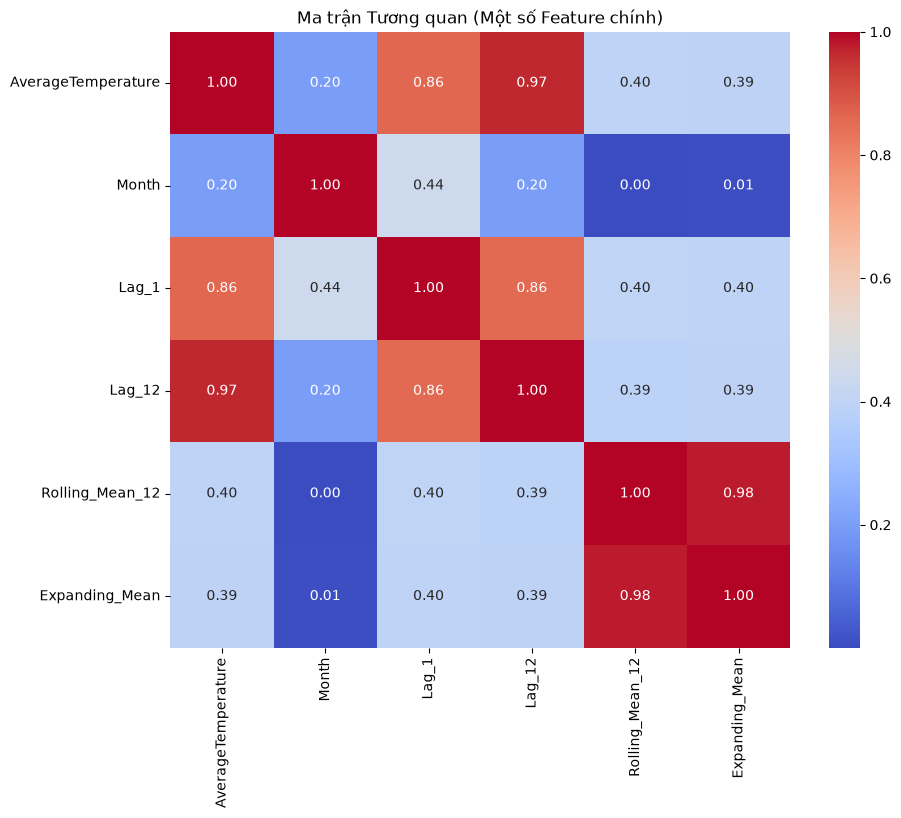

✅ Đã lưu thành công dữ liệu Feature cho 5 thành phố vào: top5_cities_features.csv!


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Vẽ ma trận tương quan để kiểm tra
plt.figure(figsize=(10,8))
cols = ['AverageTemperature', 'Month', 'Lag_1', 'Lag_12', 'Rolling_Mean_12', 'Expanding_Mean']
sns.heatmap(city_df[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận Tương quan (Một số Feature chính)')
plt.show()

# Lưu dữ liệu an toàn
city_df.to_csv('../data/processed/top5_cities_features.csv')
print("✅ Đã lưu thành công dữ liệu Feature cho 5 thành phố vào: top5_cities_features.csv!")

## V. Lưu dữ liệu mới

In [4]:
city_df.to_csv('../data/processed/tokyo_features.csv')
print("Đã lưu dữ liệu features!")

Đã lưu dữ liệu features!
